In [ ]:
# =============================================================
# EDA — Dataset 4: GHArchive 2022 (JSON) — ShiftMetrics Analytics
# Dataset: 24 archivos JSON.gz, 1.7 GiB
# Bucket:  gs://shiftmetrics-bronze/gharchive/
# Objetivo: tipos de eventos, proxies DORA (Deploy Freq, CFR)
# =============================================================

In [2]:
# ── 0. Autenticación GCP + Imports ───────────────────────────────────────────
try:
    from google.colab import auth
    auth.authenticate_user()
    print('✅ Autenticado en Colab')
except ImportError:
    print('⚠️ Entorno local detectado (usa gcloud auth application-default login)')
print("✅ Autenticado")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import io, os, gzip, json
from collections import Counter, defaultdict

pd.set_option('display.max_columns', 40)
sns.set_theme(style='darkgrid')

PROJECT = 'shiftmetrics-analytics'
BUCKET  = 'shiftmetrics-bronze'
PREFIX  = 'gharchive/'
print("✅ Imports OK")

⚠️ Entorno local detectado (usa gcloud auth application-default login)
✅ Autenticado
✅ Imports OK


*Auth + Imports combinados en celda anterior*

In [3]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import storage
import io, os, gzip, json
from collections import Counter, defaultdict

pd.set_option('display.max_columns', 40)
sns.set_theme(style='darkgrid')

PROJECT = 'shiftmetrics-analytics'
BUCKET  = 'shiftmetrics-bronze'
PREFIX  = 'gharchive/'
print("✅ Imports OK")

✅ Imports OK


In [4]:
# ── 2. Listar archivos JSON.gz ────────────────────────────────────────────────
client = storage.Client(project=PROJECT)
bucket = client.bucket(BUCKET)

blobs = list(bucket.list_blobs(prefix=PREFIX))
json_blobs = [b for b in blobs if b.name.endswith('.json.gz') or b.name.endswith('.gz')]

print(f"Archivos JSON.gz encontrados: {len(json_blobs)}")
total_size = sum(b.size for b in json_blobs) / (1024**3)
print(f"Tamaño total: {total_size:.2f} GiB")
print("\nArchivos (primeros 20):")
for b in json_blobs[:20]:
    print(f"  {b.name:50s}  {b.size/(1024**2):.1f} MB")

Archivos JSON.gz encontrados: 24
Tamaño total: 1.69 GiB

Archivos (primeros 20):
  gharchive/2022-01-01-0.json.gz                      40.6 MB
  gharchive/2022-01-01-12.json.gz                     43.9 MB
  gharchive/2022-01-01-18.json.gz                     40.2 MB
  gharchive/2022-01-01-6.json.gz                      29.3 MB
  gharchive/2022-01-15-0.json.gz                      56.4 MB
  gharchive/2022-01-15-12.json.gz                     45.9 MB
  gharchive/2022-01-15-18.json.gz                     44.9 MB
  gharchive/2022-01-15-6.json.gz                      156.2 MB
  gharchive/2022-02-01-0.json.gz                      87.9 MB
  gharchive/2022-02-01-12.json.gz                     94.2 MB
  gharchive/2022-02-01-18.json.gz                     93.8 MB
  gharchive/2022-02-01-6.json.gz                      54.8 MB
  gharchive/2022-02-15-0.json.gz                      83.5 MB
  gharchive/2022-02-15-12.json.gz                     87.3 MB
  gharchive/2022-02-15-18.json.gz                 

In [5]:
# ── 3. Cargar eventos de repos Apache (Todos los archivos) ────────────────────
# Filtro: repo_name.startswith('apache/') — solo repos de la Apache Software Foundation.
# NO usar actor_login: captura usuarios con 'apache' en su username sin relación con la ASF.
all_events = []

for blob in json_blobs:
    print(f"\nCargando: {blob.name} ({blob.size/(1024**2):.1f} MB)")
    data = blob.download_as_bytes()
    count = 0
    apache_count = 0

    try:
        with gzip.open(io.BytesIO(data), 'rt', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    event = json.loads(line)
                    count += 1
                    repo_name = (event.get('repo', {}).get('name', '') or '').lower()
                    if repo_name.startswith('apache/'):
                        all_events.append(event)
                        apache_count += 1
                except json.JSONDecodeError:
                    pass
        print(f"  ✅ {count:,} eventos procesados | {apache_count:,} de Apache guardados")
    except Exception as e:
        print(f"  ❌ Error: {e}")

print(f"\nTotal eventos Apache cargados: {len(all_events):,}")


Cargando: gharchive/2022-01-01-0.json.gz (40.6 MB)
  ✅ 84,925 eventos procesados | 85 de Apache guardados

Cargando: gharchive/2022-01-01-12.json.gz (43.9 MB)
  ✅ 103,853 eventos procesados | 116 de Apache guardados

Cargando: gharchive/2022-01-01-18.json.gz (40.2 MB)
  ✅ 99,150 eventos procesados | 57 de Apache guardados

Cargando: gharchive/2022-01-01-6.json.gz (29.3 MB)
  ✅ 76,222 eventos procesados | 40 de Apache guardados

Cargando: gharchive/2022-01-15-0.json.gz (56.4 MB)
  ✅ 107,551 eventos procesados | 144 de Apache guardados

Cargando: gharchive/2022-01-15-12.json.gz (45.9 MB)
  ✅ 115,999 eventos procesados | 155 de Apache guardados

Cargando: gharchive/2022-01-15-18.json.gz (44.9 MB)
  ✅ 111,940 eventos procesados | 101 de Apache guardados

Cargando: gharchive/2022-01-15-6.json.gz (156.2 MB)
  ✅ 189,027 eventos procesados | 100 de Apache guardados

Cargando: gharchive/2022-02-01-0.json.gz (87.9 MB)
  ✅ 141,472 eventos procesados | 176 de Apache guardados

Cargando: gharchive

Tipos de eventos únicos: 13

Distribución:
  IssueCommentEvent                     1,094  (21.9%)
  PullRequestReviewEvent                1,085  (21.7%)
  PullRequestReviewCommentEvent           796  (15.9%)
  PullRequestEvent                        656  (13.1%)
  PushEvent                               589  (11.8%)
  WatchEvent                              304  (6.1%)
  IssuesEvent                             182  (3.6%)
  ForkEvent                               162  (3.2%)
  CreateEvent                              72  (1.4%)
  DeleteEvent                              46  (0.9%)
  CommitCommentEvent                        5  (0.1%)
  ReleaseEvent                              2  (0.0%)
  GollumEvent                               1  (0.0%)


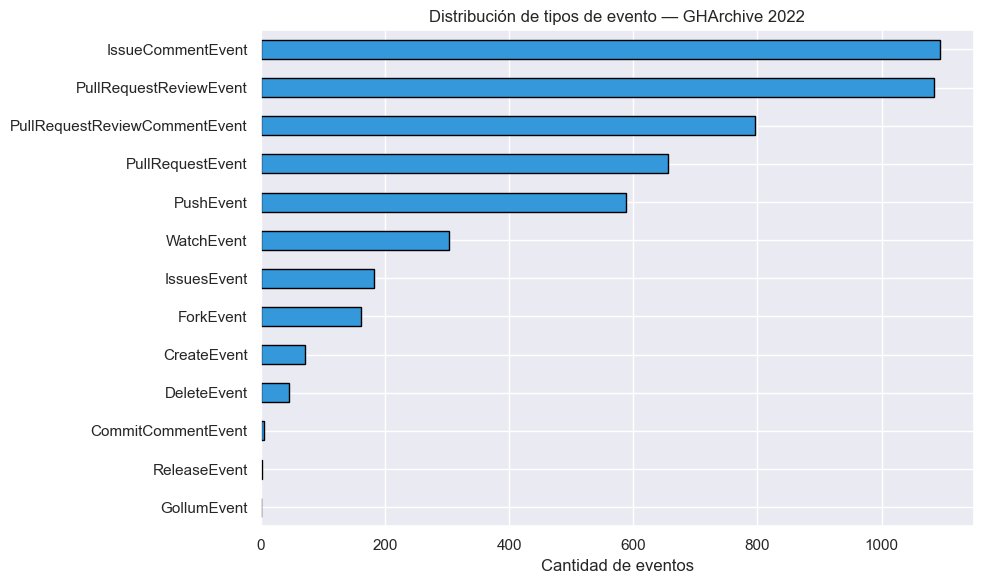


🎯 Eventos relevantes para proxies DORA:
  PushEvent                          589  (11.8%)
  PullRequestEvent                   656  (13.1%)
  CreateEvent                         72  (1.4%)
  ReleaseEvent                         2  (0.0%)
  IssuesEvent                        182  (3.6%)
  IssueCommentEvent                1,094  (21.9%)
  WorkflowRunEvent                     0  (0.0%)


In [6]:
# ── 4. Distribución de tipos de eventos ──────────────────────────────────────
event_types = Counter(e.get('type', 'unknown') for e in all_events)

print(f"Tipos de eventos únicos: {len(event_types)}")
print("\nDistribución:")
for etype, cnt in event_types.most_common():
    pct = cnt / len(all_events) * 100
    print(f"  {etype:35s}  {cnt:6,}  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
event_series = pd.Series(dict(event_types.most_common()))
event_series.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_title('Distribución de tipos de evento — GHArchive 2022')
ax.set_xlabel('Cantidad de eventos')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('gharchive_event_types.png', dpi=120)
plt.show()

# Eventos relevantes para DORA
DORA_EVENTS = ['PushEvent', 'PullRequestEvent', 'CreateEvent', 'ReleaseEvent',
               'IssuesEvent', 'IssueCommentEvent', 'WorkflowRunEvent']
dora_counts = {e: event_types.get(e, 0) for e in DORA_EVENTS}
print(f"\n🎯 Eventos relevantes para proxies DORA:")
for e, c in dora_counts.items():
    print(f"  {e:30s}  {c:6,}  ({c/len(all_events)*100:.1f}%)")

In [7]:
# ── 5. Estructura de eventos clave ───────────────────────────────────────────
for event_type in ['PushEvent', 'PullRequestEvent', 'IssuesEvent']:
    sample_events = [e for e in all_events if e.get('type') == event_type][:3]
    if sample_events:
        print(f"\n=== {event_type} — campos de 1 ejemplo ===")
        e = sample_events[0]
        print(f"Top-level keys: {list(e.keys())}")
        if 'payload' in e:
            print(f"payload keys: {list(e['payload'].keys())[:15]}")
        if 'repo' in e:
            print(f"repo: {e['repo']}")
        if 'actor' in e:
            print(f"actor: {list(e['actor'].keys()) if isinstance(e['actor'], dict) else e['actor']}")
    else:
        print(f"\n⚠️ No se encontraron eventos de tipo {event_type} en la muestra")


=== PushEvent — campos de 1 ejemplo ===
Top-level keys: ['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']
payload keys: ['push_id', 'size', 'distinct_size', 'ref', 'head', 'before', 'commits']
repo: {'id': 17165658, 'name': 'apache/spark', 'url': 'https://api.github.com/repos/apache/spark'}
actor: ['id', 'login', 'display_login', 'gravatar_id', 'url', 'avatar_url']

=== PullRequestEvent — campos de 1 ejemplo ===
Top-level keys: ['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']
payload keys: ['action', 'number', 'pull_request']
repo: {'id': 17165658, 'name': 'apache/spark', 'url': 'https://api.github.com/repos/apache/spark'}
actor: ['id', 'login', 'display_login', 'gravatar_id', 'url', 'avatar_url']

=== IssuesEvent — campos de 1 ejemplo ===
Top-level keys: ['id', 'type', 'actor', 'repo', 'payload', 'public', 'created_at', 'org']
payload keys: ['action', 'issue']
repo: {'id': 146865191, 'name': 'apache/camel-k', 'url': 'https://api.github

PushEvents en muestra: 589

Repos con pushes a main/master: 118

Top 15 repos por deployments:
apache/camel               11
apache/airflow             10
apache/incubator-nuttx      9
apache/myfaces-tobago       8
apache/beam                 7
apache/hbase                6
apache/arrow                6
apache/spark                6
apache/tinkerpop            6
apache/shardingsphere       6
apache/flink                6
apache/trafficserver        5
apache/maven-dist-tool      5
apache/arrow-rs             5
apache/incubator-inlong     5


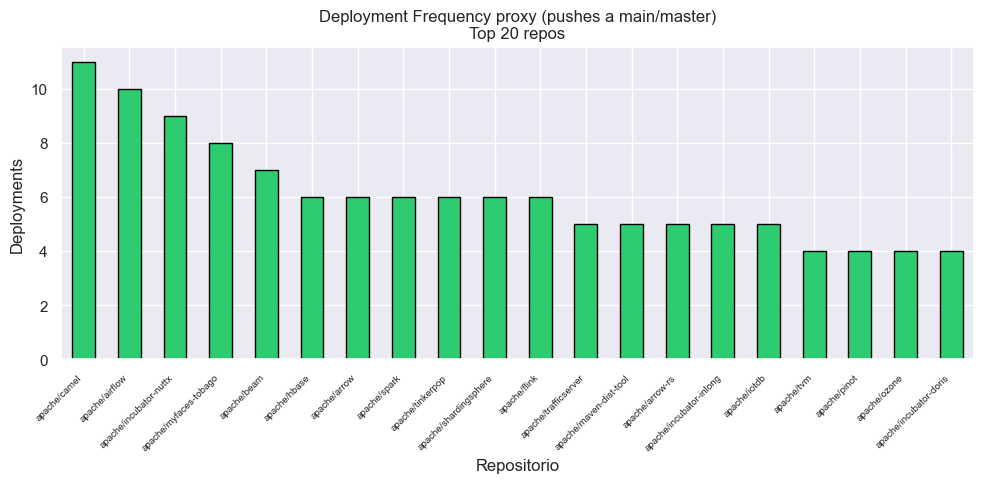

In [8]:
# ── 6. Proxy Deployment Frequency (PushEvent a main/master) ─────────────────
push_events = [e for e in all_events if e.get('type') == 'PushEvent']
print(f"PushEvents en muestra: {len(push_events):,}")

deployments_by_repo = defaultdict(list)
for e in push_events:
    repo = e.get('repo', {}).get('name', 'unknown')
    payload = e.get('payload', {})
    ref = payload.get('ref', '')
    created_at = e.get('created_at', '')

    # Solo pushes a main/master como proxy de deployment
    if ref in ['refs/heads/main', 'refs/heads/master']:
        deployments_by_repo[repo].append(created_at)

print(f"\nRepos con pushes a main/master: {len(deployments_by_repo):,}")
if deployments_by_repo:
    deploy_counts = pd.Series({k: len(v) for k, v in deployments_by_repo.items()})
    deploy_counts = deploy_counts.sort_values(ascending=False)
    print(f"\nTop 15 repos por deployments:")
    print(deploy_counts.head(15).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    deploy_counts.head(20).plot(kind='bar', ax=ax, color='#2ecc71', edgecolor='black')
    ax.set_title('Deployment Frequency proxy (pushes a main/master)\nTop 20 repos')
    ax.set_xlabel('Repositorio'); ax.set_ylabel('Deployments')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    plt.tight_layout()
    plt.savefig('gharchive_deployment_freq.png', dpi=120)
    plt.show()

In [9]:
# ── 7. Proxy Change Failure Rate (PullRequests cerrados como failed) ──────────
pr_events = [e for e in all_events if e.get('type') == 'PullRequestEvent']
print(f"PullRequestEvents en muestra: {len(pr_events):,}")

pr_actions = Counter()
pr_merged = 0
pr_closed_not_merged = 0

for e in pr_events:
    payload = e.get('payload', {})
    action = payload.get('action', 'unknown')
    pr_actions[action] += 1

    if action == 'closed':
        pr = payload.get('pull_request', {})
        if pr.get('merged', False):
            pr_merged += 1
        else:
            pr_closed_not_merged += 1

print(f"\nAcciones de PR: {dict(pr_actions)}")
total_closed = pr_merged + pr_closed_not_merged
if total_closed > 0:
    cfr_proxy = pr_closed_not_merged / total_closed
    print(f"\n📊 Proxy Change Failure Rate:")
    print(f"   PRs merged:              {pr_merged:,}")
    print(f"   PRs cerrados sin merge:  {pr_closed_not_merged:,}")
    print(f"   CFR proxy:               {cfr_proxy:.3f} ({cfr_proxy*100:.1f}%)")
else:
    print("⚠️ Sin PRs closed en la muestra")

PullRequestEvents en muestra: 656

Acciones de PR: {'closed': 345, 'opened': 307, 'reopened': 4}

📊 Proxy Change Failure Rate:
   PRs merged:              255
   PRs cerrados sin merge:  90
   CFR proxy:               0.261 (26.1%)


Rango temporal: 2022-01-01 00:01:39+00:00 → 2022-03-15 18:59:56+00:00

Eventos Apache por hora del día:
0     1033
6     1409
12    1490
18    1062


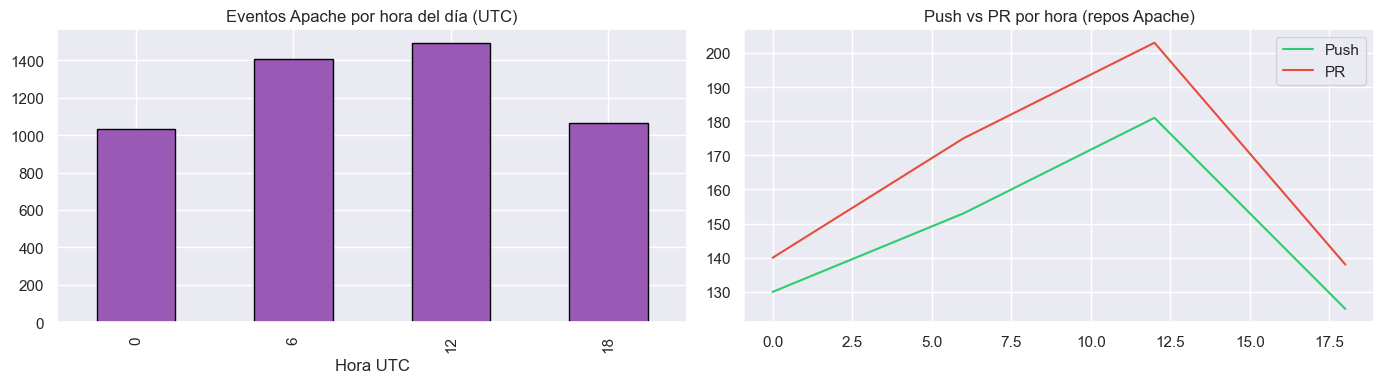

In [10]:
# ── 8. Distribución temporal de eventos ──────────────────────────────────────
# FIX: pd.to_datetime() sobre lista devuelve DatetimeIndex (sin .dt).
#      Envolver en pd.Series() para poder usar .dt.hour correctamente.
timestamps = [e.get('created_at', '') for e in all_events if e.get('created_at')]

if timestamps:
    dates = pd.Series(pd.to_datetime(timestamps, errors='coerce')).dropna()
    print(f"Rango temporal: {dates.min()} → {dates.max()}")

    hour_dist = dates.dt.hour.value_counts().sort_index()
    print(f"\nEventos Apache por hora del día:")
    print(hour_dist.to_string())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    hour_dist.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='black')
    ax1.set_title('Eventos Apache por hora del día (UTC)')
    ax1.set_xlabel('Hora UTC')

    push_ts = [e['created_at'] for e in all_events if e.get('type') == 'PushEvent']
    pr_ts   = [e['created_at'] for e in all_events if e.get('type') == 'PullRequestEvent']
    push_hours = pd.Series(pd.to_datetime(push_ts, errors='coerce')).dropna().dt.hour
    pr_hours   = pd.Series(pd.to_datetime(pr_ts,   errors='coerce')).dropna().dt.hour
    push_hours.value_counts().sort_index().plot(ax=ax2, label='Push', color='#2ecc71')
    pr_hours.value_counts().sort_index().plot(ax=ax2, label='PR',    color='#e74c3c')
    ax2.set_title('Push vs PR por hora (repos Apache)')
    ax2.legend()
    plt.tight_layout()
    plt.savefig('gharchive_temporal.png', dpi=120)
    plt.show()
else:
    print("⚠️ Sin timestamps en all_events")

In [11]:
# ── 9. Filtrar eventos de repos Apache (para alinear con Jira) ───────────────
# NOTA: El filtrado ya se realizó durante la carga (Celda 3) para optimizar memoria.
apache_events = all_events
print(f"Eventos relacionados con Apache listos: {len(apache_events):,}")

if apache_events:
    apache_repos = Counter(e.get('repo', {}).get('name', '') for e in apache_events)
    print("\nTop 20 repos Apache:")
    for repo, cnt in apache_repos.most_common(20):
        print(f"  {repo:50s}  {cnt:4,}")

    apache_types = Counter(e.get('type', '') for e in apache_events)
    print("\nTipos de eventos Apache:")
    print(dict(apache_types))
else:
    print("⚠️ Sin eventos Apache.")


Eventos relacionados con Apache listos: 4,994

Top 20 repos Apache:
  apache/airflow                                       247
  apache/spark                                         211
  apache/arrow                                         208
  apache/pulsar                                        176
  apache/beam                                          163
  apache/hudi                                          135
  apache/flink                                         125
  apache/tvm                                           122
  apache/dolphinscheduler                              121
  apache/iceberg                                       116
  apache/incubator-nuttx                               115
  apache/iotdb                                         114
  apache/superset                                      109
  apache/cloudstack                                     94
  apache/camel                                          88
  apache/pinot                                 

In [12]:
# ── 10. Resumen EDA — parámetros para Silver ─────────────────────────────────
print("=" * 65)
print("RESUMEN EDA — GHARCHIVE 2022")
print("=" * 65)
print(f"\n📁 Archivos JSON.gz en Bronze: {len(json_blobs)}")
print(f"📊 Eventos analizados (muestra): {len(all_events):,}")
print(f"🎭 Tipos de eventos únicos: {len(event_types)}")

print("\n🎯 Conteos de eventos relevantes para DORA:")
for e, c in dora_counts.items():
    print(f"   {e:30s}: {c:,}")

if 'cfr_proxy' in dir():
    print(f"\n📊 CFR proxy (muestra): {cfr_proxy:.3f}")

print(f"""
🔧 PARÁMETROS PARA JOB SILVER GHARCHIVE:
   - Filtrar eventos útiles: PushEvent, PullRequestEvent, IssuesEvent, CreateEvent
   - Filtrar repos Apache (para cruce con Jira)
   - Calcular por repo/mes:
     * Deployment Frequency = pushes a main/master por mes
     * Change Failure Rate = PRs cerrados sin merge / total PRs cerrados
   - Aplanar campos: repo.name, actor.login, payload.ref, created_at
   - Particionar por: repo_org (ej: 'apache'), año, mes

🔧 PARÁMETROS PARA GOLD:
   - Unir GHArchive con Apache Jira por: repo_name ↔ jira_project_key
   - Ventana temporal: mes → sprint (aprox 2 semanas)
   - Métricas DORA para tabla sprint_features
""")
print("✅ EDA GHArchive completado")

RESUMEN EDA — GHARCHIVE 2022

📁 Archivos JSON.gz en Bronze: 24
📊 Eventos analizados (muestra): 4,994
🎭 Tipos de eventos únicos: 13

🎯 Conteos de eventos relevantes para DORA:
   PushEvent                     : 589
   PullRequestEvent              : 656
   CreateEvent                   : 72
   ReleaseEvent                  : 2
   IssuesEvent                   : 182
   IssueCommentEvent             : 1,094
   WorkflowRunEvent              : 0

📊 CFR proxy (muestra): 0.261

🔧 PARÁMETROS PARA JOB SILVER GHARCHIVE:
   - Filtrar eventos útiles: PushEvent, PullRequestEvent, IssuesEvent, CreateEvent
   - Filtrar repos Apache (para cruce con Jira)
   - Calcular por repo/mes:
     * Deployment Frequency = pushes a main/master por mes
     * Change Failure Rate = PRs cerrados sin merge / total PRs cerrados
   - Aplanar campos: repo.name, actor.login, payload.ref, created_at
   - Particionar por: repo_org (ej: 'apache'), año, mes

🔧 PARÁMETROS PARA GOLD:
   - Unir GHArchive con Apache Jira por: re